In [23]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 你的矩阵（注意第三行是 1, -5, 3, -3）
A = np.array([
    [ 2,  0,  1, -1],
    [-5,  1,  3, -4],
    [ 1, -5,  3, -3],
    [ 3,  1, -1,  2]
], dtype=float)

# 方法 1：直接调用 NumPy
det = np.linalg.det(A)
print("numpy 计算行列式 =", det)          # 应为 40.0

numpy 计算行列式 = 40.0


In [6]:
A = np.array([
    [ 1,  2, -1],
    [ 3,  4, -2],
    [ 5, -4,  1]
], dtype=float)

# 方法 1：NumPy 直接求逆
A_inv = np.linalg.inv(A)
print("NumPy 逆矩阵:\n", A_inv)

# 验证 A @ A_inv 是否接近单位阵
print("A @ A_inv =\n", np.round(A @ A_inv, 10))

NumPy 逆矩阵:
 [[-2.00000000e+00  1.00000000e+00  1.33226763e-16]
 [-6.50000000e+00  3.00000000e+00 -5.00000000e-01]
 [-1.60000000e+01  7.00000000e+00 -1.00000000e+00]]
A @ A_inv =
 [[ 1.  0. -0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


In [8]:
# 用 Rational 定义，保证是精确分数而非浮点
A = sp.Matrix([
    [sp.Rational(1),  sp.Rational(2),  sp.Rational(-1)],
    [sp.Rational(3),  sp.Rational(4),  sp.Rational(-2)],
    [sp.Rational(5),  sp.Rational(-4), sp.Rational(1)]
])

A_inv = A.inv()        # 精确逆矩阵
print("精确分数逆矩阵:")
display(A_inv)

# 验证 A * A_inv 是否等于单位阵
print("A * A_inv =")
print(display(sp.simplify(A * A_inv)))

精确分数逆矩阵:


Matrix([
[   -2, 1,    0],
[-13/2, 3, -1/2],
[  -16, 7,   -1]])

A * A_inv =


Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

None


In [10]:
sp.init_printing()

A = sp.Matrix([
    [-2, 2, 2],
    [ 0, 2, 0],
    [-2, 1, 3]
])

# 方法 2：SymPy 精确解
eigs = A.eigenvects()      # 返回 [(特征值, 代数重数, [特征向量列表]), ...]
print("精确特征值与特征向量:")
for val, mult, vecs in eigs:
    print(f"λ = {val}  (重数 {mult})")
    for v in vecs:
        display(v)

# 也可只看特征值
print("特征多项式:", sp.factor(A.charpoly().as_expr()))

精确特征值与特征向量:
λ = -1  (重数 1)


⎡2⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

λ = 2  (重数 2)


⎡1/2⎤
⎢   ⎥
⎢ 1 ⎥
⎢   ⎥
⎣ 0 ⎦

⎡1/2⎤
⎢   ⎥
⎢ 0 ⎥
⎢   ⎥
⎣ 1 ⎦

特征多项式: (lambda - 2)**2*(lambda + 1)


In [3]:
A = sp.Matrix([
    [1, 4, -2],
    [0, -1, 0],
    [1, 2, -2]
])

# SymPy 精确对角化
P, D = A.diagonalize()      # 返回 (P, D) 使得 A = P * D * P^{-1}
print("P ="); display(P)
print("D ="); display(D)

# 验证
print("P * D * P^{-1} ="); display(sp.simplify(P * D * P.inv()))
print("是否等于 A:", sp.simplify(P * D * P.inv()) == A)

P =


Matrix([
[-2, 1, 2],
[ 1, 0, 0],
[ 0, 1, 1]])

D =


Matrix([
[-1,  0, 0],
[ 0, -1, 0],
[ 0,  0, 0]])

P * D * P^{-1} =


Matrix([
[1,  4, -2],
[0, -1,  0],
[1,  2, -2]])

是否等于 A: True


In [17]:
A = sp.Matrix([
    [ 1,  1, -2],
    [ 1,  5,  0],
    [-2,  0,  5]
])

def orthonormalize(vecs):
    """对一组向量做 Gram-Schmidt 正交单位化（精确符号版）"""
    basis = []
    for v in vecs:
        u = v
        for b in basis:
            u = u - (v.dot(b) / b.dot(b)) * b
        if u.dot(u) != 0:                       # 跳过线性相关的零向量
            basis.append(u / sp.sqrt(sp.simplify(u.dot(u))))
    return basis

# 1) 收集所有特征向量
vecs = []
for val, mult, basis in A.eigenvects():
    vecs.extend(basis)

# 2) 正交单位化 -> 组装正交阵 Q
Q_cols = orthonormalize(vecs)
Q = sp.Matrix.hstack(*Q_cols)

# 3) 对角阵 D = Q^T A Q（取对角元）
tmp = sp.simplify(Q.T * A * Q)
D = sp.diag(*[tmp[i, i] for i in range(A.rows)])
Q_inv = Q.inv()

print("正交矩阵 Q ="); display(Q)
print("Q_inv ="); display(Q_inv)
print("对角阵 D =");   display(D)
print("Q^T A Q =");    display(tmp)
print("Q^T Q = I ?", sp.simplify(Q.T * Q) == sp.eye(3))
print("A = Q D Q^T ?", sp.simplify(Q * D * Q.T) == A)

正交矩阵 Q =


⎡ √30         -√6 ⎤
⎢ ───    0    ────⎥
⎢  6           6  ⎥
⎢                 ⎥
⎢-√30   2⋅√5  -√6 ⎥
⎢─────  ────  ────⎥
⎢ 30     5     6  ⎥
⎢                 ⎥
⎢ √30    √5    √6 ⎥
⎢ ───    ──    ── ⎥
⎣ 15     5     3  ⎦

Q_inv =


⎡√30   -√30   √30⎤
⎢───   ─────  ───⎥
⎢ 6     30    15 ⎥
⎢                ⎥
⎢      2⋅√5   √5 ⎥
⎢ 0    ────   ── ⎥
⎢       5     5  ⎥
⎢                ⎥
⎢-√6   -√6    √6 ⎥
⎢────  ────   ── ⎥
⎣ 6     6     3  ⎦

对角阵 D =


⎡0  0  0⎤
⎢       ⎥
⎢0  5  0⎥
⎢       ⎥
⎣0  0  6⎦

Q^T A Q =


⎡0  0  0⎤
⎢       ⎥
⎢0  5  0⎥
⎢       ⎥
⎣0  0  6⎦

Q^T Q = I ? True
A = Q D Q^T ? True


In [16]:
Q_inv = Q.inv()
print("Q_inv ="); display(Q_inv)

Q_inv =


⎡√30   -√30   √30⎤
⎢───   ─────  ───⎥
⎢ 6     30    15 ⎥
⎢                ⎥
⎢      2⋅√5   √5 ⎥
⎢ 0    ────   ── ⎥
⎢       5     5  ⎥
⎢                ⎥
⎢-√6   -√6    √6 ⎥
⎢────  ────   ── ⎥
⎣ 6     6     3  ⎦

In [19]:
X = np.array([
    [2, 2],
    [2, 6],
    [4, 6],
    [8, 8],
    [4, 8]
], dtype=float)

mean = X.mean(axis=0)
Xc = X - mean

# 协方差矩阵（等价于 np.cov(X.T)）
Sigma = (Xc.T @ Xc) / (X.shape[0] - 1)
print("协方差矩阵:\n", Sigma)

# 特征分解（对称矩阵用 eigh）
eigvals, eigvecs = np.linalg.eigh(Sigma)        # 升序
idx = eigvals.argsort()[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
print("特征值(方差):", eigvals)
print("主成分方向(列):\n", eigvecs)

# 新空间特征
Y = Xc @ eigvecs
print("新空间坐标 Y:\n", np.round(Y, 4))
print("方差解释率:", eigvals / eigvals.sum())

# 验证 Y 的协方差应为对角阵 diag(10, 2)
print("Y 的协方差对角阵:\n", np.round((Y.T @ Y)/(X.shape[0]-1), 4))

协方差矩阵:
 [[6. 4.]
 [4. 6.]]
特征值(方差): [10.  2.]
主成分方向(列):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
新空间坐标 Y:
 [[-4.2426 -1.4142]
 [-1.4142  1.4142]
 [ 0.      0.    ]
 [ 4.2426 -1.4142]
 [ 1.4142  1.4142]]
方差解释率: [0.83333333 0.16666667]
Y 的协方差对角阵:
 [[10.  0.]
 [ 0.  2.]]


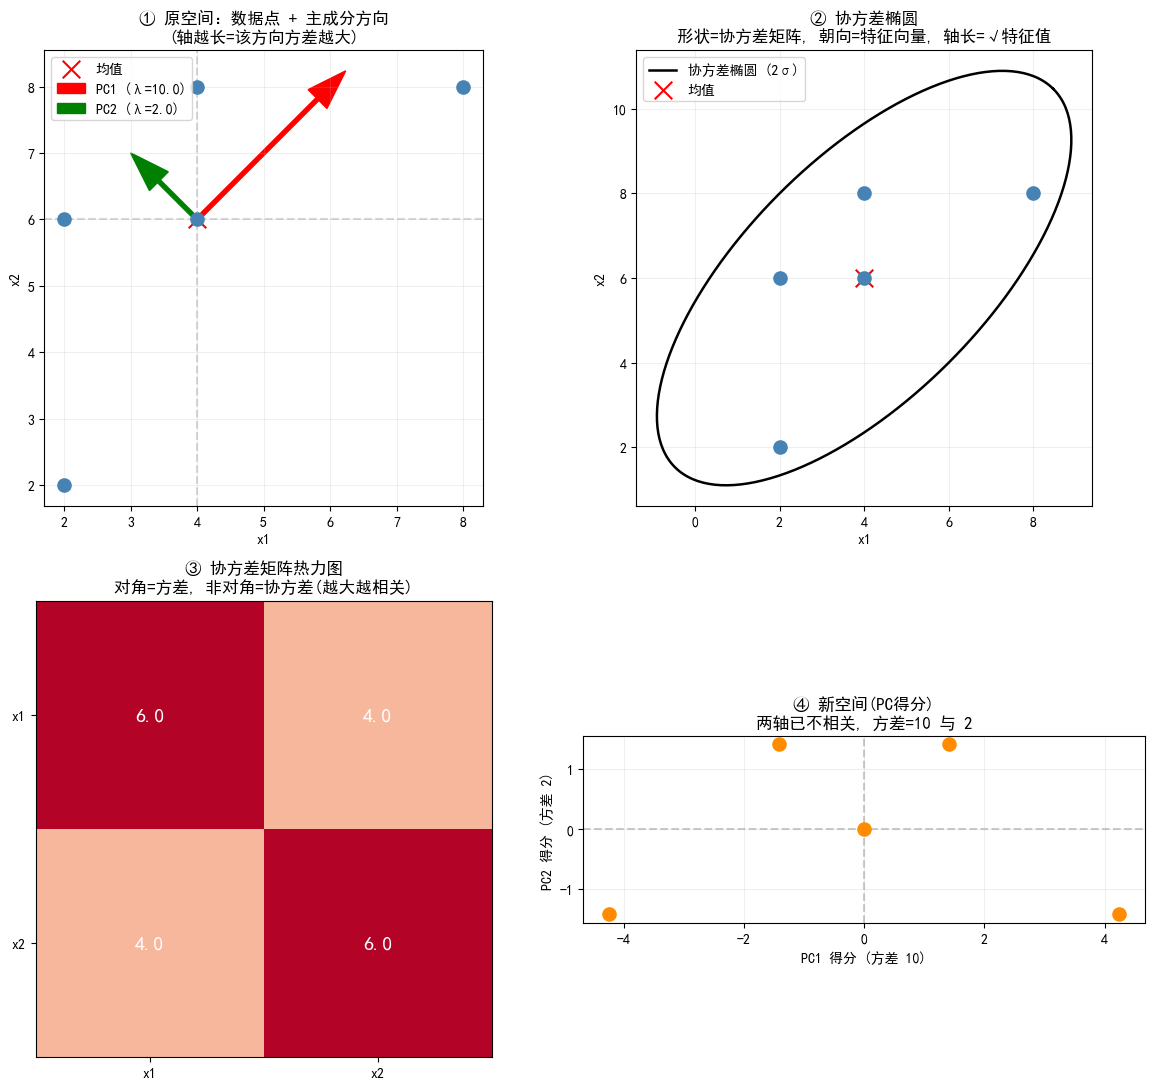

In [24]:
# ---------- 数据 ----------
X = np.array([[2,2],[2,6],[4,6],[8,8],[4,8]], dtype=float)
mean = X.mean(axis=0)
Xc = X - mean

# ---------- 协方差 + PCA ----------
Sigma = (Xc.T @ Xc) / (X.shape[0]-1)      # 或用 np.cov(X.T)
eigvals, eigvecs = np.linalg.eigh(Sigma)   # 升序
idx = eigvals.argsort()[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
Y = Xc @ eigvecs                           # 新空间(PC得分)

# ---------- 画图 ----------
fig, axs = plt.subplots(2, 2, figsize=(12, 11))

# (1) 原空间散点 + 主成分方向
ax = axs[0,0]
ax.scatter(X[:,0], X[:,1], s=90, c='steelblue', zorder=3)
ax.scatter(mean[0], mean[1], s=160, c='red', marker='x', label='均值')
for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i])      # 轴长 = √特征值(方差)
    ax.arrow(mean[0], mean[1], vec[0], vec[1],
             color=['red','green'][i], width=0.06, head_width=0.4,
             length_includes_head=True,
             label=f'PC{i+1} (λ={eigvals[i]:.1f})')
ax.axvline(mean[0], ls='--', c='gray', alpha=0.3)
ax.axhline(mean[1], ls='--', c='gray', alpha=0.3)
ax.set_title("① 原空间：数据点 + 主成分方向\n(轴越长=该方向方差越大)")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.legend(); ax.grid(alpha=0.2); ax.set_aspect('equal')

# (2) 协方差椭圆
ax = axs[0,1]
ax.scatter(X[:,0], X[:,1], s=90, c='steelblue', zorder=3)
t = np.linspace(0, 2*np.pi, 300)
unit = np.array([np.cos(t), np.sin(t)])            # 单位圆
A = eigvecs * (np.sqrt(eigvals)*2)[np.newaxis, :]  # 每列按 √λ·2 缩放(2σ)
ellipse = mean[:, np.newaxis] + A @ unit
ax.plot(ellipse[0], ellipse[1], 'k-', lw=1.8, label='协方差椭圆 (2σ)')
ax.scatter(mean[0], mean[1], s=160, c='red', marker='x', label='均值')
ax.set_title("② 协方差椭圆\n形状=协方差矩阵, 朝向=特征向量, 轴长=√特征值")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.legend(); ax.grid(alpha=0.2); ax.set_aspect('equal')

# (3) 协方差矩阵热力图
ax = axs[1,0]
im = ax.imshow(Sigma, cmap='coolwarm', vmin=0, vmax=6)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['x1','x2']); ax.set_yticklabels(['x1','x2'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{Sigma[i,j]:.1f}', ha='center', va='center',
                color='white' if Sigma[i,j]>3 else 'black', fontsize=14)
ax.set_title("③ 协方差矩阵热力图\n对角=方差, 非对角=协方差(越大越相关)")

# (4) 新空间(主成分得分)
ax = axs[1,1]
ax.scatter(Y[:,0], Y[:,1], s=90, c='darkorange', zorder=3)
ax.axvline(0, ls='--', c='gray', alpha=0.4)
ax.axhline(0, ls='--', c='gray', alpha=0.4)
ax.set_title("④ 新空间(PC得分)\n两轴已不相关, 方差=10 与 2")
ax.set_xlabel("PC1 得分 (方差 10)"); ax.set_ylabel("PC2 得分 (方差 2)")
ax.grid(alpha=0.2); ax.set_aspect('equal')

plt.tight_layout()
plt.show()